In [1]:
import h5ify
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bilby.core.result import read_in_result

from util import plot_multiple

In [2]:
from data import get_data

_, _, _, ln_evidences = get_data(
    snr_thresh=10,
    far_thresh=1,
    prefer_xphm=False,
    prefer_xphm_gwtc3=True,
    return_ln_evidence=True
)

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5


In [3]:
ln_noise_z = np.sum(ln_evidences)

$$ quick check: mass dist used by salvo iso injs

In [ ]:
/ceph/submit/data/user/s/svitale/runs/Tilts_prod_PE_iso/injs/PE_Injs_iso_seed333

In [ ]:
allinjs = pd.read_csv(
    '/ceph/submit/data/user/s/svitale/runs/Tilts_prod_PE_iso/injs/PE_Injs_iso_seed333/allinjs_list_O4.dat',
    sep='\t',
    header=0
)

In [ ]:
fig, ax = plt.subplots()
bins = np.linspace(0, 1, 50)
ax.hist(allinjs['a_1'], histtype='step', bins=bins, density=True, color='C0', label=r'$a_1$')
ax.hist(allinjs['a_2'], histtype='step', bins=bins, density=True, linestyle='--', color='C1', label=r'$a_2$');
ax.legend()
ax.set_xlim(0, 1);
ax.set_xlabel('spin magnitude');
ax.set_ylabel(r'$p(a_{1,2})$')

Text(0, 0.5, '$p(a_{1,2})$')

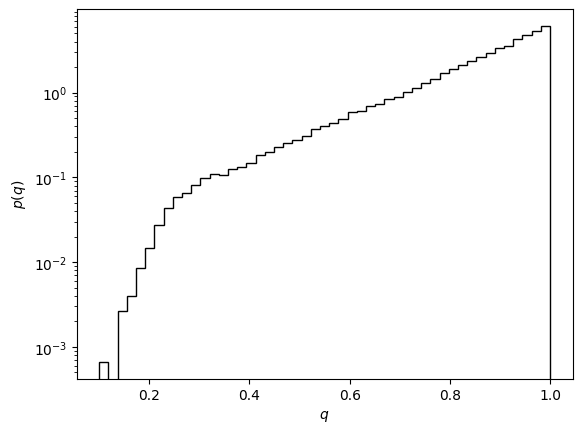

In [17]:
fig, ax = plt.subplots()
bins = np.linspace(0.1, 1, 50)
ax.hist(allinjs['mass_ratio'], histtype='step', bins=bins, density=True, color='black')
ax.set_yscale('log')
ax.set_ylabel(r'$p(q)$')
ax.set_xlabel(r'$q$');

# Onemass (bpl2p)

In [4]:
pdir = '../../data/inference/strong/multimass/noah/bpl2p/nlive500/constrain_mu_order'

In [5]:
r1 = read_in_result(f'{pdir}/ascending/run_result.hdf5')

In [6]:
r2 = read_in_result(f'{pdir}/descending/run_result.hdf5')

In [8]:
lnz_1 = r1.log_bayes_factor #+ ln_noise_z
lnz_2 = r2.log_bayes_factor #+ ln_noise_z

In [9]:
ln_norm = np.logaddexp(lnz_1, lnz_2)

In [10]:
ln_w1 = lnz_1 - ln_norm
ln_w2 = lnz_2 - ln_norm

In [11]:
ln_weights = np.concatenate([
    ln_w1 * np.ones(len(r1.posterior)),
    ln_w2 * np.ones(len(r2.posterior))
])
ln_weights -= ln_weights.max()
weights = np.exp(ln_weights)

In [12]:
r1.posterior['mu_1'] = r1.posterior['g_0']
r1.posterior['mu_2'] = r1.posterior['g_0'] + r1.posterior['g_1']

r2.posterior['mu_2'] = r2.posterior['g_0']
r2.posterior['mu_1'] = r2.posterior['g_0'] + r2.posterior['g_1']

unweighted_res = pd.concat([r1.posterior, r2.posterior])

In [13]:
rng = np.random.default_rng(seed=260228)
keep = rng.uniform(size=len(weights)) < weights

In [14]:
xi_onemass = unweighted_res['weight_a'].values[keep]

In [15]:
onemass = unweighted_res.iloc[keep]

In [18]:
big_res = h5ify.load(
    f'../../data/inference/strong/multimass/noah/bpl2p/sampling_seed/merged.h5'
)

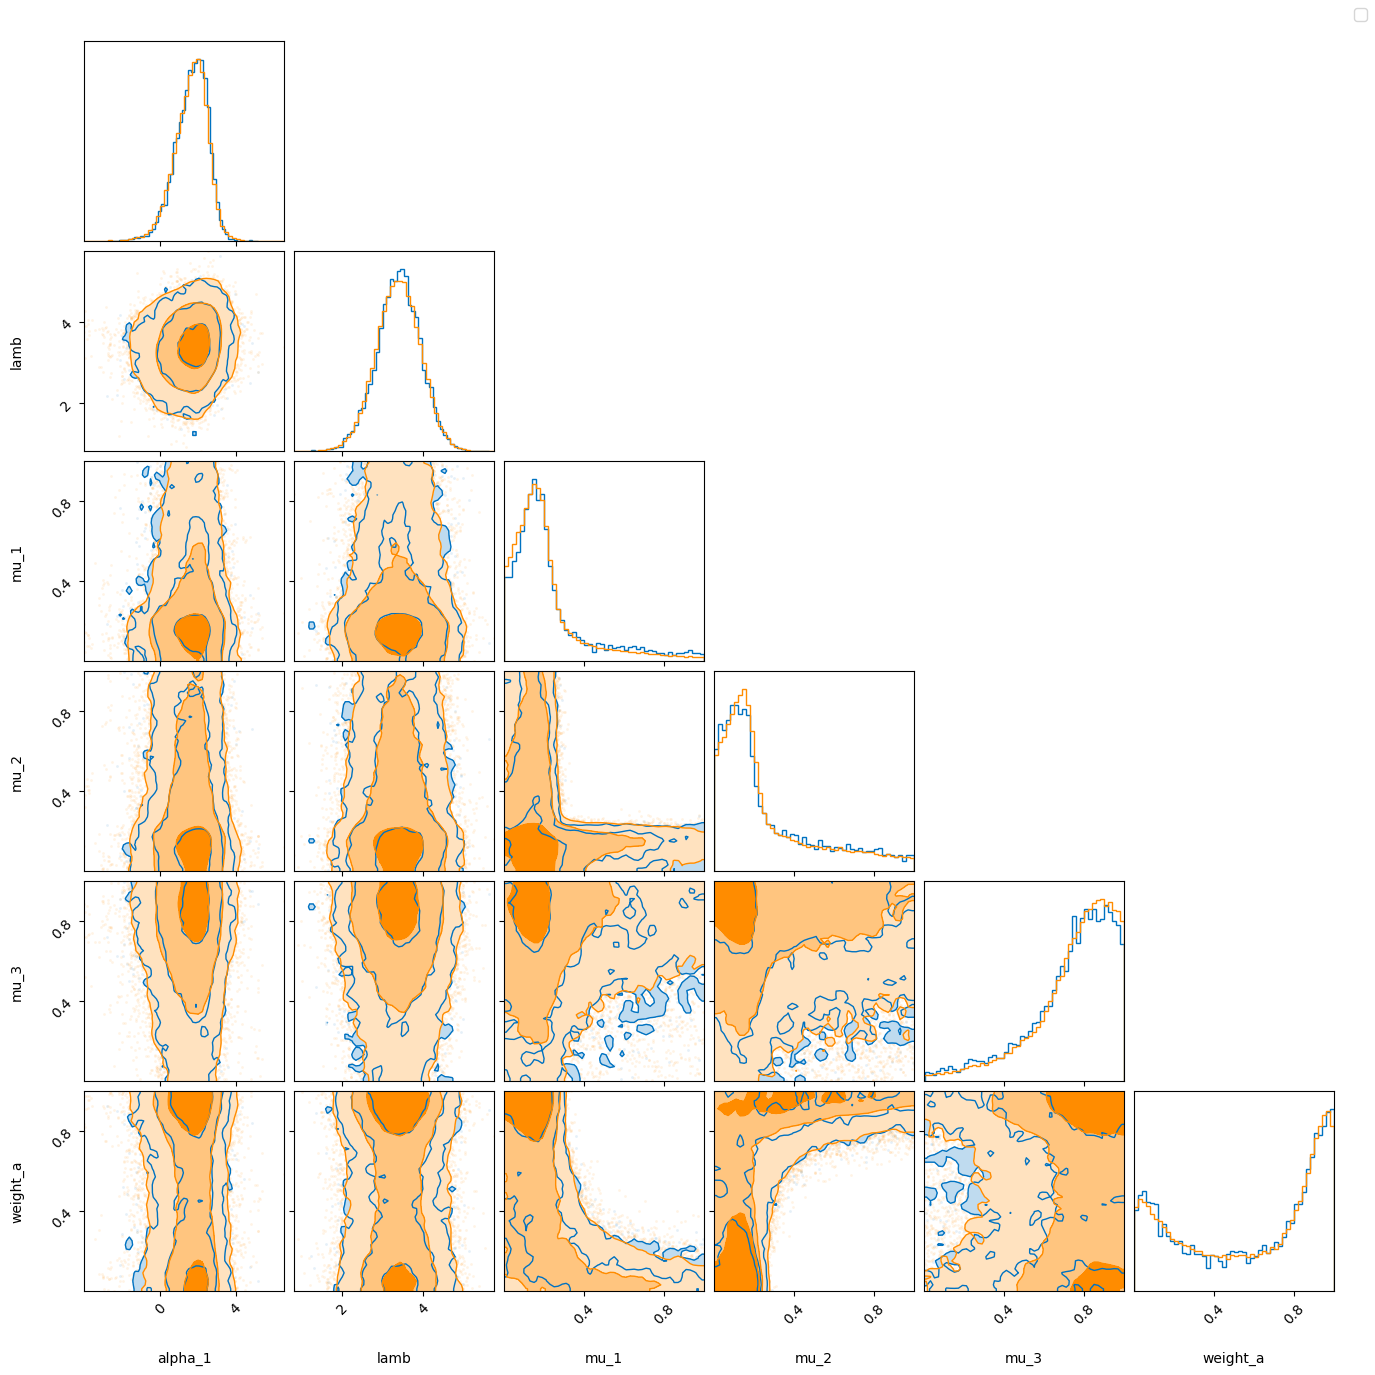

In [20]:
keys = ['alpha_1', 'lamb', 'mu_1', 'mu_2', 'mu_3', 'weight_a']

fig = plot_multiple(
    [
        np.column_stack([ onemass[k] for k in keys ]),
        np.column_stack([ big_res[k] for k in keys ])
    ],
    labels=keys
)

In [64]:
cw1 = h5ify.load(f'{pdir}/ascending/components-and-weights.h5')
cw2 = h5ify.load(f'{pdir}/descending/components-and-weights.h5')

In [65]:
cw = {
    k : np.concatenate([cw1[k], cw2[k]])
    for k in cw1.keys()
}

In [66]:
def tilt_ppd(cw, weights):
    for param in ['cos_tilt']:
        fig, ax = plt.subplots()

        if param == 'cos_tilt':
            xs = np.linspace(-1, 1, 500)
            ax.set_ylim(0, 1.5)
            ax.set_xlim(-1, 1)
            ax.set_xlabel(r'$\cos \theta_{1,2}$')
        elif param == 'chi':
            xs = np.linspace(0, 1, 500)
            ax.set_ylim(-0.1, 3.0)
            ax.set_xlim(0, 1)
            ax.set_xlabel(r'$\chi_{1,2}$')

        prob1 = cw[param] * cw['weight'][:, None]
        med = np.quantile(prob1, 0.5, axis=0, weights=weights, method='inverted_cdf')
        q05 = np.quantile(prob1, 0.05, axis=0, weights=weights, method='inverted_cdf')
        q95 = np.quantile(prob1, 0.95, axis=0, weights=weights, method='inverted_cdf')
        ax.plot(xs, med, color='C0', lw=2, label='truncnorm tilts')
        ax.plot(xs, q05, color='C0', lw=1)
        ax.plot(xs, q95, color='C0', lw=1)

        # iso component
        prob2 = 0.5 * np.ones_like(cw[param]) * cw['weight_iso'][:, None]
        med = np.quantile(prob2, 0.5, axis=0, weights=weights, method='inverted_cdf')
        q05 = np.quantile(prob2, 0.05, axis=0, weights=weights, method='inverted_cdf')
        q95 = np.quantile(prob2, 0.95, axis=0, weights=weights, method='inverted_cdf')
        ax.plot(xs, med, color='C1', lw=2, label='Low-mass iso tilts')
        ax.plot(xs, q05, color='C1', lw=1)
        ax.plot(xs, q95, color='C1', lw=1)

        # high-iso component
        prob3 = 0.5 * np.ones_like(cw[param]) * cw['weight_high_iso'][:, None]
        med = np.quantile(prob3, 0.5, axis=0, weights=weights, method='inverted_cdf')
        q05 = np.quantile(prob3, 0.05, axis=0, weights=weights, method='inverted_cdf')
        q95 = np.quantile(prob3, 0.95, axis=0, weights=weights, method='inverted_cdf')
        ax.plot(xs, med, color='C2', lw=2, label='High-mass iso tilts')
        ax.plot(xs, q05, color='C2', lw=1)
        ax.plot(xs, q95, color='C2', lw=1)

        prob = prob1 + prob2 + prob3
        med = np.quantile(prob, 0.5, axis=0, weights=weights, method='inverted_cdf')
        q05 = np.quantile(prob, 0.05, axis=0, weights=weights, method='inverted_cdf')
        q95 = np.quantile(prob, 0.95, axis=0, weights=weights, method='inverted_cdf')
        ax.plot(xs, med, color='C3', lw=2, label='Weighted sum')
        ax.fill_between(xs, q05, q95, alpha=0.2, color=f'C3', lw=0)

        ax.axhline(y=0, lw=0.5, color='grey')
        
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        
        ax.legend(
            handles=[                
                *[(
                    Patch(edgecolor=f'C{i}', facecolor='none', lw=1),
                    Line2D([], [], color=f'C{i}', lw=2)
                )
                for i in range(3)
                ],
                (
                    Patch(color='C3', alpha=0.2, lw=0),
                    Line2D([], [], color='C3', lw=2)
                )
            ],
            labels=[
                'Truncnorm tilts',
                'Low-mass, isotropic tilts',
                'High-mass, isotropic tilts',
                'Weighted sum'
            ],
        )
        
        ax.grid()
        
        ax.set_box_aspect(1)

    return fig, ax

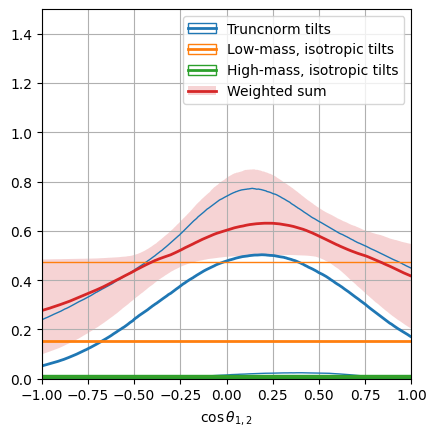

In [19]:
tilt_ppd(cw, weights);

# Twomass

In [85]:
pdir = '../../data/inference/strong/multimass/noah/twomass'

In [86]:
r1 = read_in_result(f'{pdir}/constrain_mu_order/ascending/run_result.hdf5')

In [87]:
r2 = read_in_result(f'{pdir}/constrain_mu_order/descending/run_result.hdf5')

In [88]:
lnz_1 = r1.log_bayes_factor + ln_noise_z
lnz_2 = r2.log_bayes_factor + ln_noise_z

In [89]:
ln_norm = np.logaddexp(lnz_1, lnz_2)

In [90]:
ln_w1 = lnz_1 - ln_norm
ln_w2 = lnz_2 - ln_norm

In [91]:
ln_weights = np.concatenate([
    ln_w1 * np.ones(len(r1.posterior)),
    ln_w2 * np.ones(len(r2.posterior))
])
ln_weights -= ln_weights.max()
weights = np.exp(ln_weights)

In [92]:
r1.posterior['mu_1'] = r1.posterior['g_0']
r1.posterior['mu_2'] = r1.posterior['g_0'] + r1.posterior['g_1']

r2.posterior['mu_2'] = r2.posterior['g_0']
r2.posterior['mu_1'] = r2.posterior['g_0'] + r2.posterior['g_1']

unweighted_res = pd.concat([r1.posterior, r2.posterior])

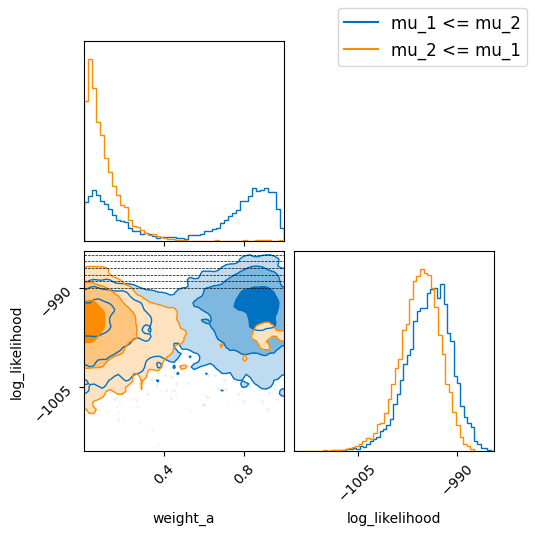

In [107]:
from util import plot_corner, plot_multiple

fig = plot_multiple(
    [r1.posterior[['weight_a', 'log_likelihood']],
    r2.posterior[['weight_a', 'log_likelihood']]],
    xs_labels=['mu_1 <= mu_2', 'mu_2 <= mu_1']
)

fig.get_axes()[2].axhline(y=-990, color='black', linestyle='--', lw=0.5)
fig.get_axes()[2].axhline(y=-989, color='black', linestyle='--', lw=0.5)
fig.get_axes()[2].axhline(y=-988, color='black', linestyle='--', lw=0.5)
fig.get_axes()[2].axhline(y=-987, color='black', linestyle='--', lw=0.5)
fig.get_axes()[2].axhline(y=-986, color='black', linestyle='--', lw=0.5)
fig.get_axes()[2].axhline(y=-985, color='black', linestyle='--', lw=0.5)

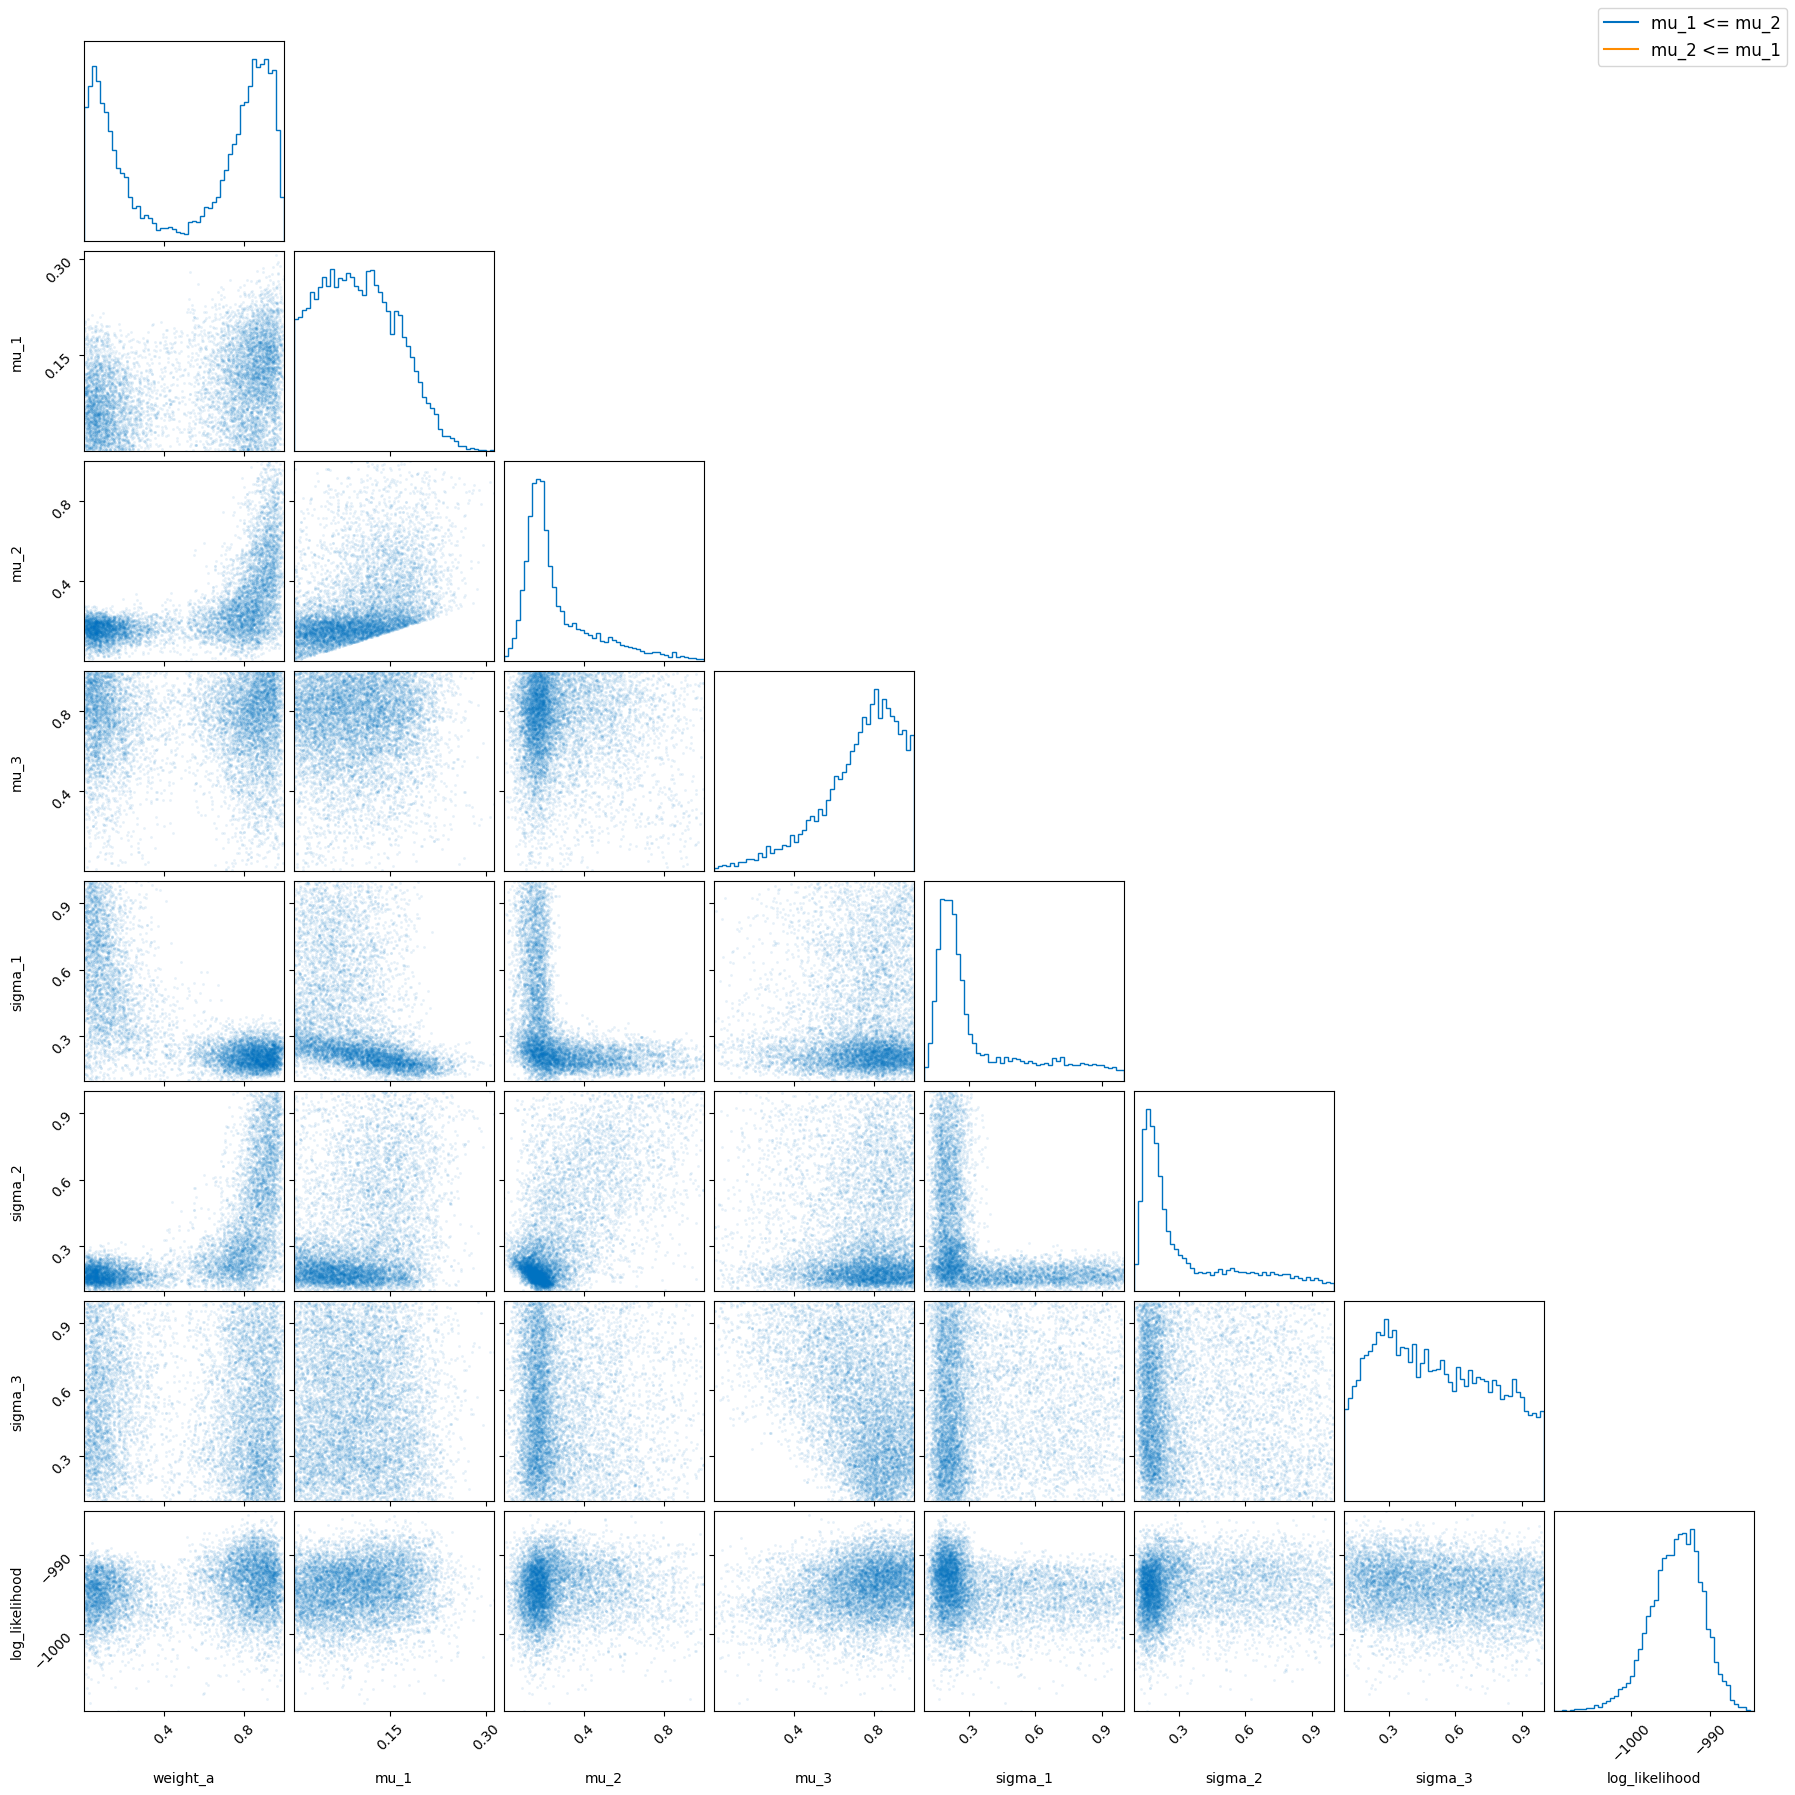

In [103]:
from util import plot_corner, plot_multiple

keys = [
    'weight_a',
    'mu_1',
    'mu_2',
    'mu_3',
    'sigma_1',
    'sigma_2',
    'sigma_3',
    'log_likelihood'
]

fig = plot_multiple(
    [
        r1.posterior[keys],
        #r2.posterior[keys]
    ],
    levels=(0.5, 0.9),
    plot_density=False,
    plot_contours=False,
    fill_contours=False,
    no_fill_contours=True,
    xs_labels=['mu_1 <= mu_2', 'mu_2 <= mu_1']
)

#fig.get_axes()[2].axhline(y=-990, color='black', linestyle='--')

In [61]:
r1.posterior['log_likelihood'].max()

np.float64(-984.4222272536842)

In [62]:
r2.posterior['log_likelihood'].max()

np.float64(-987.4583173717449)

In [12]:
rng = np.random.default_rng(seed=260228)
keep = rng.uniform(size=len(weights)) < weights
xi_twomass = unweighted_res['weight_a'].values[keep]

In [13]:
twomass = unweighted_res.iloc[keep]

In [15]:
twomass['log_likelihood'].max()

np.float64(-985.1270686733926)

In [19]:
results = []
for seed in range(1701, 1711):
    results.append(
        read_in_result(
            f'{pdir}/sampling_seed/{seed}/run_result.hdf5'
        ).posterior
    )

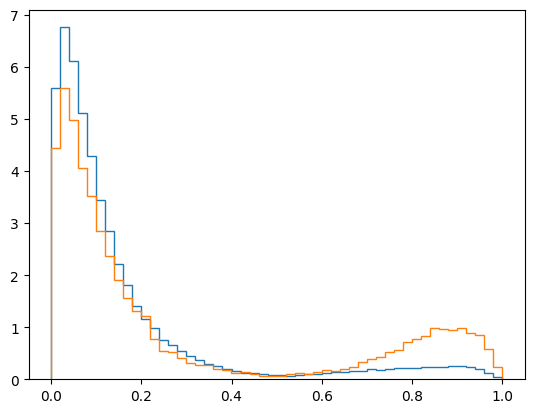

In [20]:
fig, ax = plt.subplots()
ax.hist(pd.concat(results)['weight_a'], histtype='step', bins=50, density=True)
ax.hist(twomass['weight_a'], histtype='step', bins=50, density=True);

In [32]:
cw1 = h5ify.load(f'{pdir}/constrain_mu_order/ascending/components-and-weights.h5')
cw2 = h5ify.load(f'{pdir}/constrain_mu_order/descending/components-and-weights.h5')

In [33]:
cw = {
    k : np.concatenate([cw1[k], cw2[k]])
    for k in cw1.keys()
}

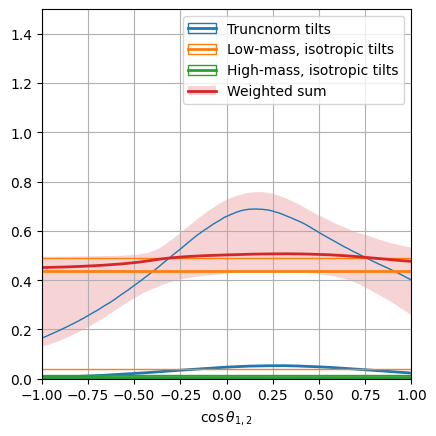

In [34]:
tilt_ppd(cw, weights);

# Threemass

In [16]:
pdir = '../../data/inference/strong/multimass/noah/threemass'

In [17]:
r1 = read_in_result(f'{pdir}/constrain_mu_order/ascending/run_result.hdf5')

In [18]:
r2 = read_in_result(f'{pdir}/constrain_mu_order/descending/run_result.hdf5')

In [19]:
lnz_1 = r1.log_bayes_factor + ln_noise_z
lnz_2 = r2.log_bayes_factor + ln_noise_z

In [20]:
ln_norm = np.logaddexp(lnz_1, lnz_2)

In [21]:
ln_w1 = lnz_1 - ln_norm
ln_w2 = lnz_2 - ln_norm

In [22]:
ln_weights = np.concatenate([
    ln_w1 * np.ones(len(r1.posterior)),
    ln_w2 * np.ones(len(r2.posterior))
])
ln_weights -= ln_weights.max()
weights = np.exp(ln_weights)

In [23]:
r1.posterior['mu_1'] = r1.posterior['g_0']
r1.posterior['mu_2'] = r1.posterior['g_0'] + r1.posterior['g_1']

r2.posterior['mu_2'] = r2.posterior['g_0']
r2.posterior['mu_1'] = r2.posterior['g_0'] + r2.posterior['g_1']

unweighted_res = pd.concat([r1.posterior, r2.posterior])

In [51]:
r1.posterior['log_likelihood'].max()

np.float64(-984.7044911887954)

In [52]:
r2.posterior['log_likelihood'].max()

np.float64(-986.0747453233582)

In [24]:
rng = np.random.default_rng(seed=260228)
keep = rng.uniform(size=len(weights)) < weights
xi_threemass = unweighted_res['weight_a'].values[keep]

In [25]:
threemass = unweighted_res.iloc[keep]

In [26]:
threemass['log_likelihood'].max()

np.float64(-984.7044911887954)

In [46]:
results_with_var = []

pdir = '../../data/inference/strong/multimass/noah/bpl2p-v1-nlive1000'

for seed in range(1701, 1711):
    results_with_var.append(
        h5ify.load(f'{pdir}/sampling_seed/{seed}/posterior.h5')
    )

In [47]:
keys = [
    'weight_a',
    'mu_1',
    'mu_2',
    'sigma_1',
    'sigma_2',
    'variance'
]

xs = np.column_stack([
    np.concatenate([ r[k] for r in results_with_var ])
    for k in keys
])

In [48]:
idxs = np.random.choice(len(xs), 10_000)

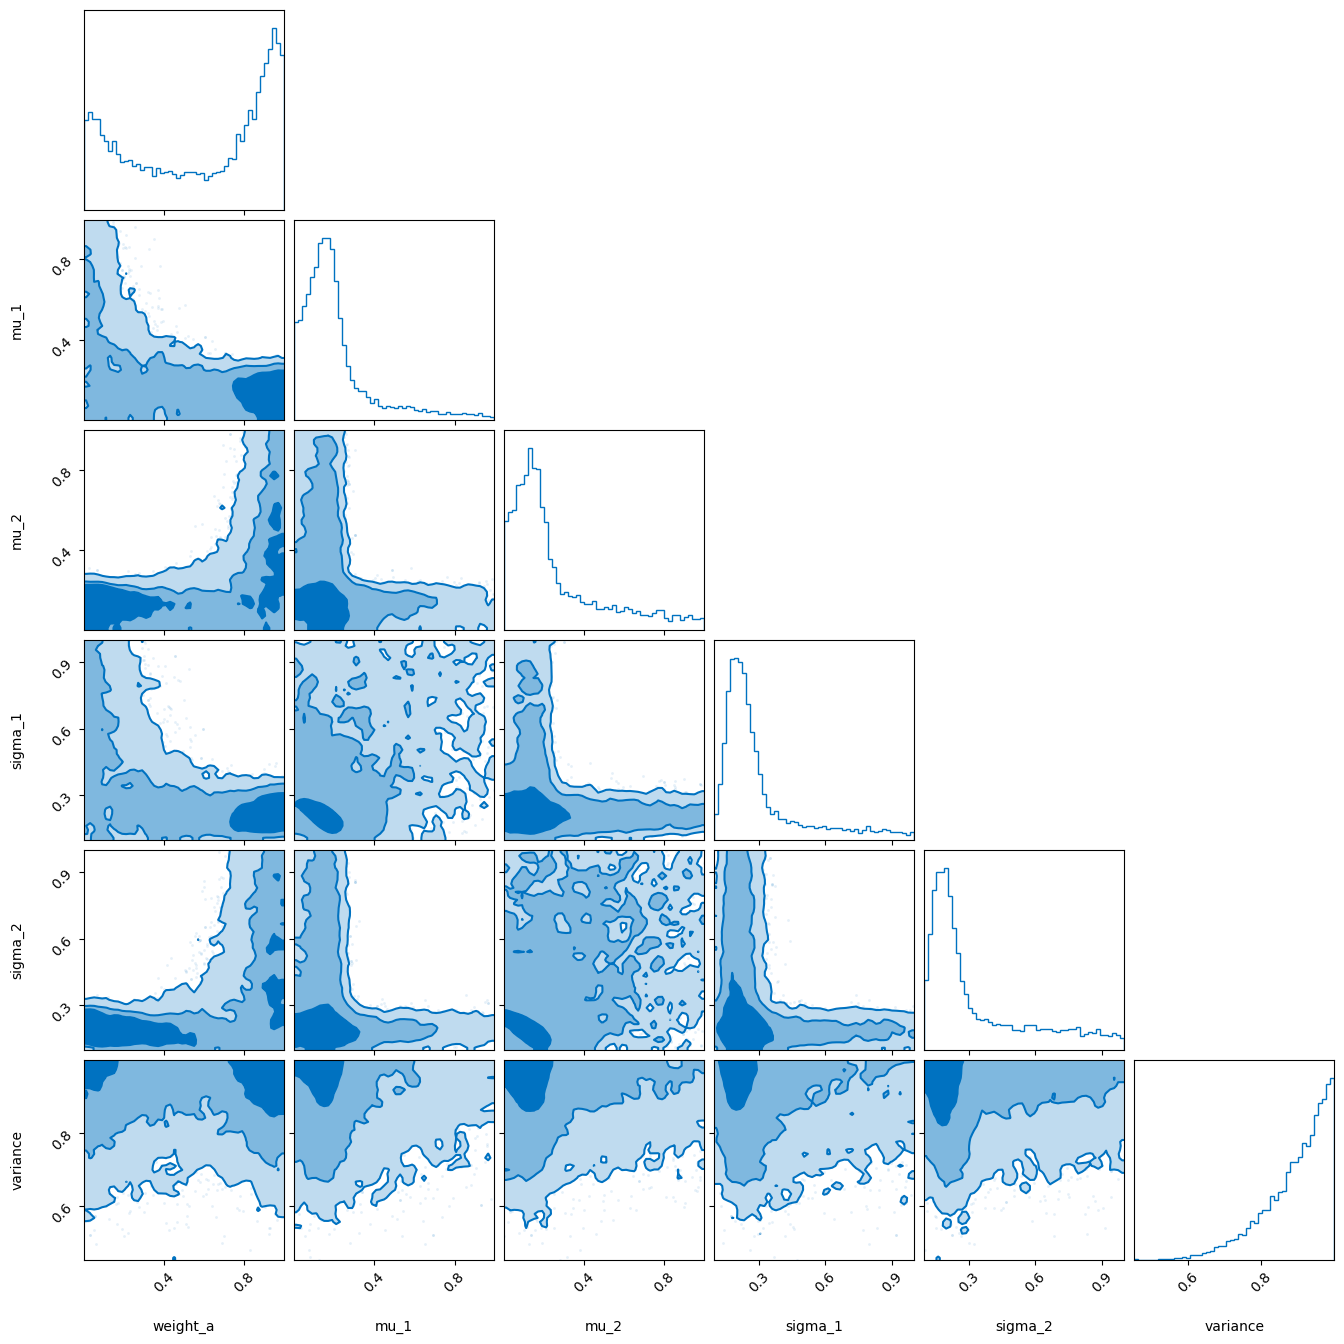

In [49]:
from util import plot_corner

fig = plot_corner(
    xs[idxs],
    labels=keys
)

In [27]:
results = []

for seed in range(1701, 1711):
    results.append(
        read_in_result(f'{pdir}/sampling_seed/{seed}/run_result.hdf5')
    )

In [29]:
big_res = pd.concat([r.posterior for r in results])

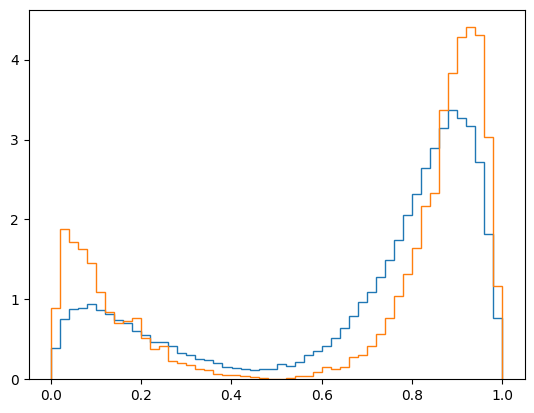

In [32]:
fig, ax = plt.subplots()
ax.hist(big_res['weight_a'], histtype='step', bins=50, density=True)
ax.hist(threemass['weight_a'], histtype='step', bins=50, density=True);

In [106]:
cw1 = h5ify.load(f'{pdir}/constrain_mu_order/ascending/components-and-weights.h5')
cw2 = h5ify.load(f'{pdir}/constrain_mu_order/descending/components-and-weights.h5')

In [107]:
cw = {
    k : np.concatenate([cw1[k], cw2[k]])
    for k in cw1.keys()
}

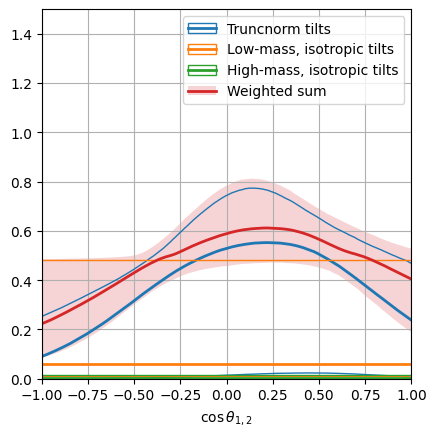

In [46]:
tilt_ppd(cw, weights);

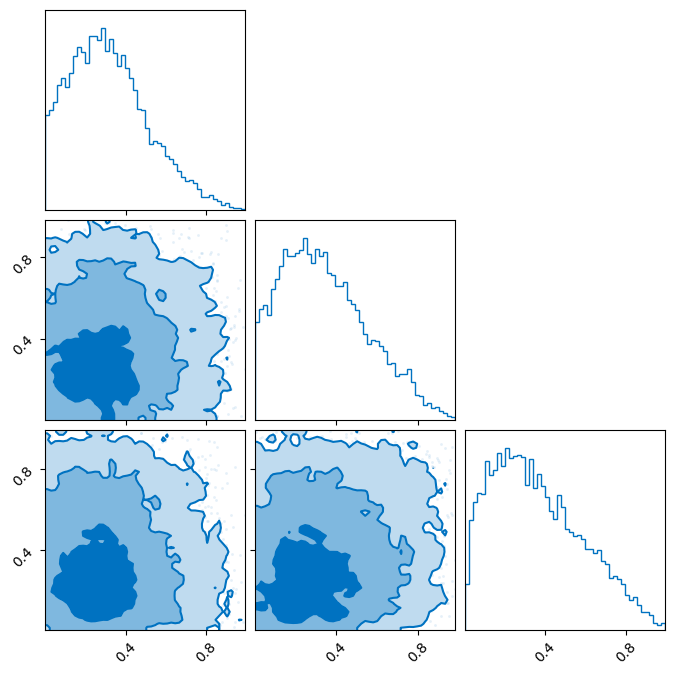

In [125]:
fig = plot_corner(
    np.column_stack([
        threemass['lam_0'],
        threemass['lam_iso_0'],
        threemass['lam_high_iso_0']
    ]),
);

In [ ]:
fig, ax = plt.subplots()
ax.hist(threemass['lamb'], histtype='step', bins=50, density=True)

(array([0.00225877, 0.00225877, 0.00112939, 0.00451755, 0.00451755,
        0.00903509, 0.01016448, 0.01581141, 0.00903509, 0.04404607,
        0.0417873 , 0.05421055, 0.11971496, 0.14456146, 0.17166673,
        0.25637071, 0.27895844, 0.35462733, 0.43933131, 0.52742345,
        0.54549363, 0.64939718, 0.69570202, 0.69570202, 0.77137091,
        0.74878318, 0.76233582, 0.83461655, 0.76572398, 0.71151343,
        0.63245638, 0.5398467 , 0.39076769, 0.40093217, 0.30154617,
        0.25298255, 0.18521937, 0.11858557, 0.0745395 , 0.06550441,
        0.03501098, 0.02823466, 0.01919957, 0.01807018, 0.00338816,
        0.00225877, 0.00225877, 0.00112939, 0.00112939, 0.00112939]),
 array([1.18137302, 1.25982744, 1.33828186, 1.41673628, 1.49519069,
        1.57364511, 1.65209953, 1.73055395, 1.80900836, 1.88746278,
        1.9659172 , 2.04437162, 2.12282603, 2.20128045, 2.27973487,
        2.35818929, 2.4366437 , 2.51509812, 2.59355254, 2.67200696,
        2.75046137, 2.82891579, 2.90737021, 2.

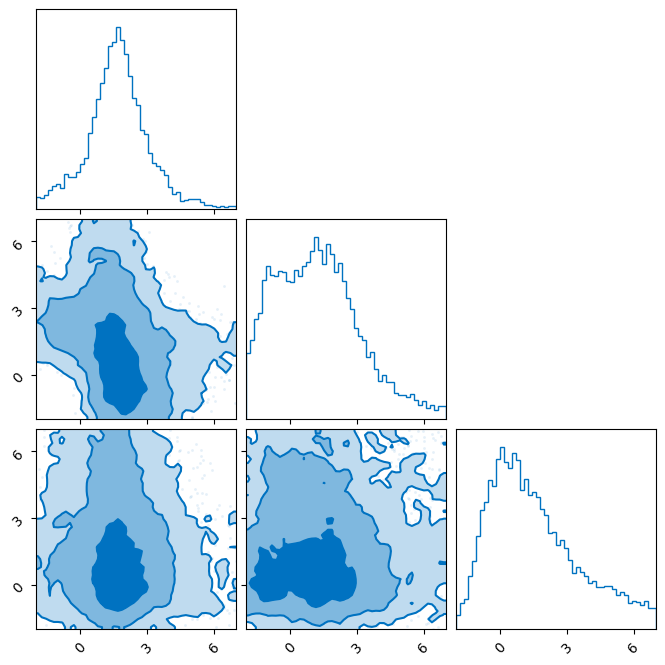

In [122]:
fig = plot_corner(
    np.column_stack([
        threemass['beta'],
        threemass['beta_iso'],
        threemass['beta_high_iso']
    ]),
);

In [ ]:
fig = plot_corner(
    np.column_stack([
        threemass['alpha_1'],
        threemass['beta_iso'],
        threemass['beta_high_iso']
    ]),
);

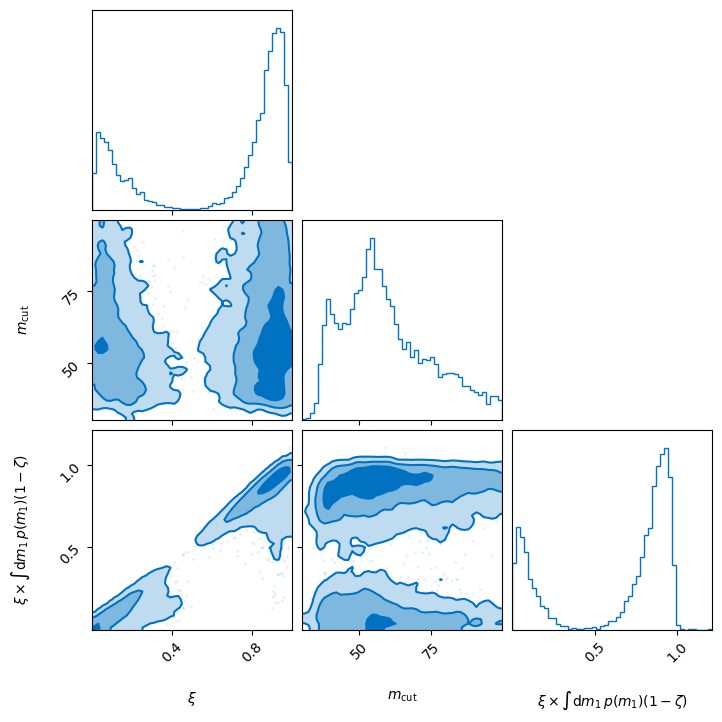

In [118]:
fig = plot_corner(
    np.column_stack([
        threemass['weight_a'],
        threemass['m_cut'],
        cw['weight'][keep]
    ]),
    labels=[
        r'$\xi$',
        r'$m_\mathrm{cut}$',
        r'$\xi \times \int \mathrm{d}m_1 \, p(m_1) (1 - \zeta)$'
    ]
);

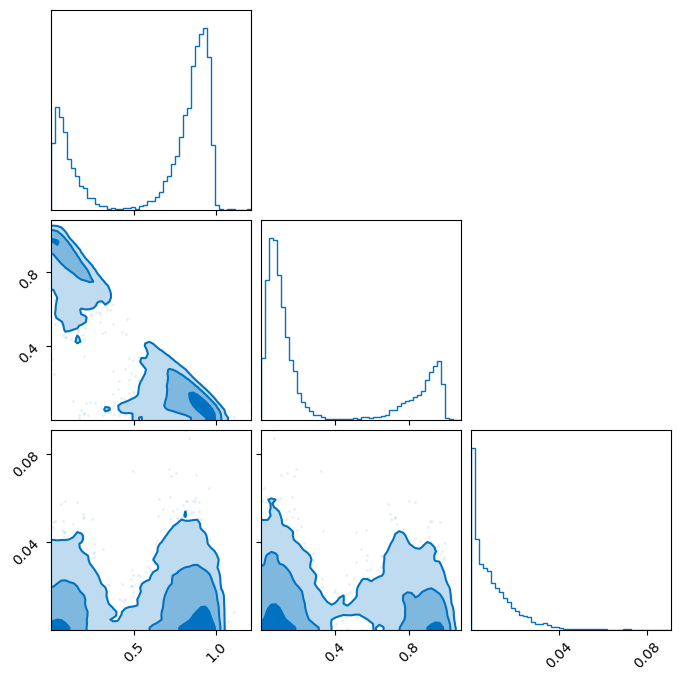

In [121]:
labels = ['']

fig = plot_corner(
    np.column_stack([
        cw['weight'][keep],
        cw['weight_iso'][keep],
        cw['weight_high_iso'][keep]
    ]),
    #labels=[
    #    r'$\xi$',
    #    r'$m_\mathrm{cut}$',
    #    r'$\xi \times \int \mathrm{d}m_1 \, p(m_1) (1 - \zeta)$'
    #]
);

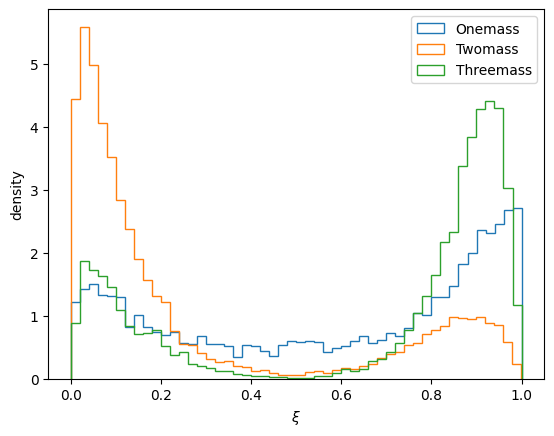

In [49]:
fig, ax = plt.subplots()
ax.hist(xi_onemass, histtype='step', bins=50, density=True, label='Onemass')
ax.hist(xi_twomass, histtype='step', bins=50, density=True, label='Twomass')
ax.hist(xi_threemass, histtype='step', bins=50, density=True, label='Threemass')

ax.set_xlabel(r'$\xi$')
ax.set_ylabel('density')

ax.legend();

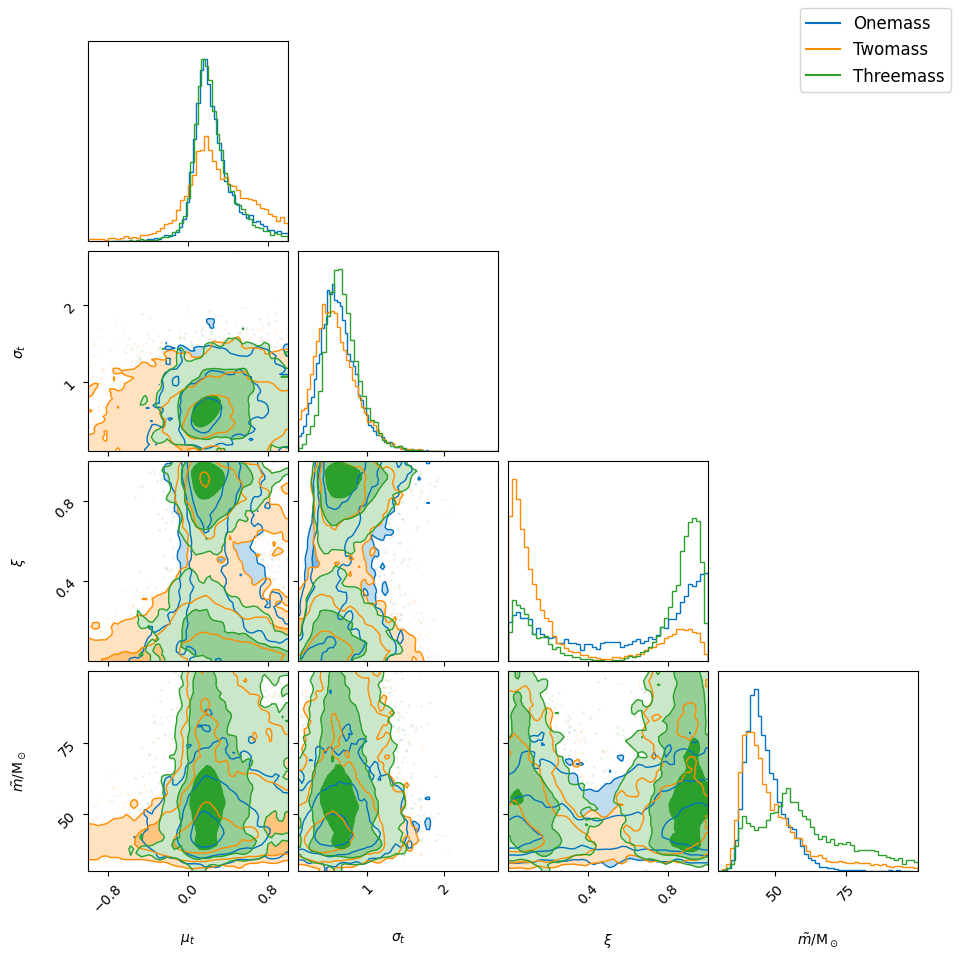

In [91]:
from util import plot_multiple

keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut']

fig = plot_multiple(
    [
        np.column_stack([r[k] for k in keys])
        for r in [onemass, twomass, threemass]
    ],
    labels=[r'$\mu_t$', r'$\sigma_t$', r'$\xi$', r'$\tilde{m} / \mathrm{M}_\odot$'],
    xs_labels=['Onemass', 'Twomass', 'Threemass']
);
